# India Salary Data Analysis
## A Statistical Analysis of 22,770 Job Records

**Dataset:** India Jobs & Salary Data  
**Tool:** Python (Pandas, Matplotlib, Seaborn)  
**Goal:** Analyze salary trends across cities and job roles in India

## 2. Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('all library')

all library


## 3. Understanding Data Types

- **Numerical columns:** Rating, Salary, Salaries Reported
- **Categorical columns:** Company Name, Job Title, Location, Employment Status, Job Roles

In [3]:
df=pd.read_csv('Salary_Dataset_with_Extra_Features.csv')
print("row",df.shape[0])
print("column",df.shape[1])

df.head(10)

row 22770
column 8


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
5,4.2,Freelancer,Android Developer,100000,3,Bangalore,Full Time,Android
6,3.7,SQUARE N CUBE,Android Developer,192000,3,Bangalore,Full Time,Android
7,3.1,Samsung R&D Institute India - Bangalore,Android Developer,400000,3,Bangalore,Full Time,Android
8,3.7,DXMinds Technologies,Android Developer,300000,3,Bangalore,Full Time,Android
9,3.6,Endeavour Software Technologies,Android Developer,600000,3,Bangalore,Full Time,Android


## 4. Descriptive Statistics
Calculating Mean, Median, Mode, Standard Deviation to understand salary distribution.

In [4]:
# find average salary from table

mean_salary=df["Salary"].mean()
print("average_salary:",mean_salary)

#Mean = Add all salaries, divide by total number of rows.

average_salary: 695387.2112428634


In [5]:
# Median (Middle Value)
median_salary = df['Salary'].median()
print('median_salary:',median_salary)

#Median = Sort all salaries, pick the middle one.
#Median is more useful than mean when some salaries are very high or very low!

median_salary: 500000.0


In [6]:
#Mode (Most Common Salary)

mode_salary = df ['Salary'].mode()[0]
print('mode_salary',mode_salary)

#Mode = Which salary appears most frequently in the data.


mode_salary 300000


In [7]:
#see all in one set
print('mean_salary:',df['Salary'].mean())
print('median_salary:',df['Salary'].median())
print('mode_salary:',df['Salary'].mode()[0])
print('min_salary:',df['Salary'].min())
print('max_salary:',df['Salary'].max())

mean_salary: 695387.2112428634
median_salary: 500000.0
mode_salary: 300000
min_salary: 2112
max_salary: 90000000


In [8]:
#STANDARD DEVIATION
std_salary = df['Salary'].std()
print('std_salary:',std_salary)

#VARIANCE
var_salary = df['Salary'].var()
print('var_salary:',var_salary)

print('\n-------salary_summary----')
print('mean              ',df['Salary'].mean())
print('median            ',df['Salary'].median())
print('standard_deviation',df['Salary'].std())
print('variance          ',df['Salary'].var())

std_salary: 884399.0136761819
var_salary: 782161615391.4034

-------salary_summary----
mean               695387.2112428634
median             500000.0
standard_deviation 884399.0136761819
variance           782161615391.4034


In [9]:
#DEFINE OUTLER LIMIT

upper_limit= df['Salary'].mean() + (3* df['Salary'].std())
lower_limit= df['Salary'].mean() - (3* df['Salary'].std())

print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)


#outliers = df[(df['Salary'] < upper_limit) | (df['Salary'] > lower_limit)]
#print('\n Total outliers found:',len(outliers))
#print(outliers[['Company Name', 'Job Title', 'Salary']].head(10))




upper_limit: 3348584.252271409
lower_limit: -1957809.8297856823


## 5. Checking Skewness & Distribution

- Skewness = 46.79 → Extreme Right Skewed
- SD Method failed because lower limit became negative (-19,57,810)
- Switching to IQR Method for outlier detection

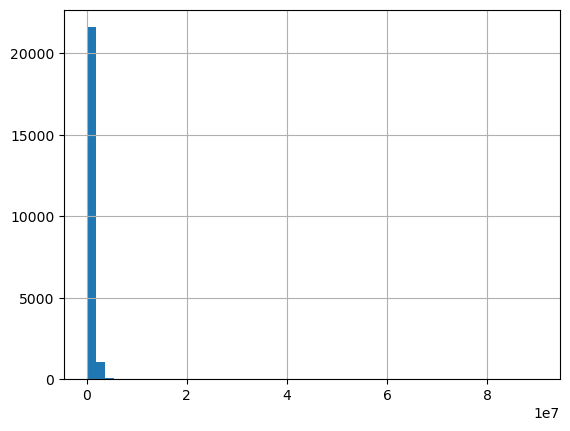

In [10]:
df['Salary'].hist(bins=50)
plt.show()

In [11]:
print(df['Salary'].skew())

46.79797994944103


## 6. Outlier Detection & Removal (IQR Method)

Since skewness = 46.79 (extreme), IQR method is used instead of SD method.

- **Q1** = 3,00,000 (25% people earn less than this)
- **Q3** = 9,00,000 (75% people earn less than this)
- **IQR** = Q3 - Q1 = 6,00,000
- **Upper Limit** = 18,00,000
- **Outliers Removed** = 1,156 rows (5% of data)
- **Skewness improved** from 46.79 → 0.99

In [13]:
# Step 1 - Q1 aur Q3 nikalo

Q1= df['Salary'].quantile(0.25)
Q3= df['Salary'].quantile(0.75)
IQR = Q3 - Q1

# Step 2 - Limits banao

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

print('Q1:',Q1)
print('Q3:',Q3)
print('IQR:',IQR)
print('lower_limit:',lower_limit)
print('upper_limit:',upper_limit)

# Step 3 - Clean data

df_clean = df[(df['Salary'] >= lower_limit) & (df['Salary'] <= upper_limit)]

print('\nbefore cleaning row:',len(df))
print('cleaning row:',len(df_clean))
print('remove outliers',len(df) - len(df_clean))

# Step 4 - Skewness compare karo
print('\nBefore skewness:',df['Salary'].skew())
print('After skewness:',df_clean['Salary'].skew())


Q1: 300000.0
Q3: 900000.0
IQR: 600000.0
lower_limit: -600000.0
upper_limit: 1800000.0

before cleaning row: 22770
cleaning row: 21614
remove outliers 1156

Before skewness: 46.79797994944103
After skewness: 0.9902526230327116


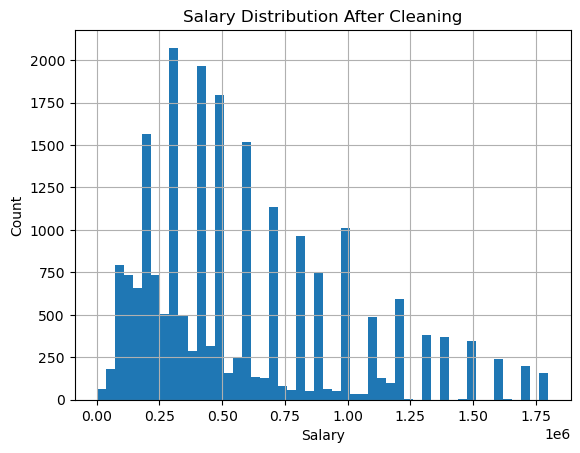

In [14]:
df_clean['Salary'].hist(bins=50)
plt.title("Salary Distribution After Cleaning")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

In [15]:
# Mean or median for cleaned data

print('Mean_salary:',df_clean['Salary'].mean())
print('Median_salary:',df_clean['Salary'].median())

Mean_salary: 584481.5715739798
Median_salary: 500000.0


## 7. Analysis After Cleaning

After removing 1,156 outliers, salary data looks much more balanced.

- **Mean** changed from 6,95,387 → 5,84,481 (more realistic)
- **Median** stayed same at 5,00,000 (outlier resistant)
- **Histogram** now shows proper distribution

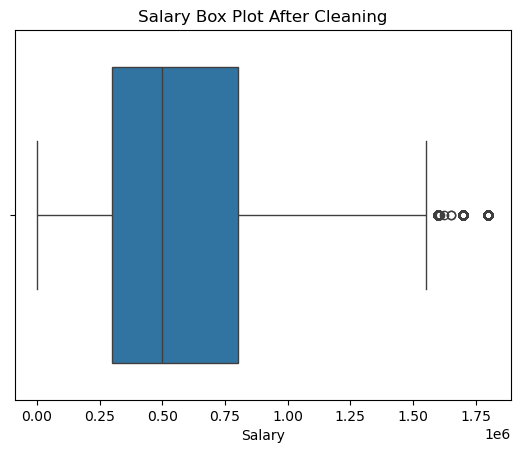

In [16]:

sns.boxplot(x=df_clean['Salary'])
plt.title("Salary Box Plot After Cleaning")
plt.show()

In [20]:
city_salary = df_clean.groupby('Location')['Salary'].mean().sort_values(ascending = False)
print(city_salary)

Location
Mumbai            752751.976155
Bangalore         606592.401189
Pune              594584.661125
Hyderabad         571350.134149
Kolkata           566359.281437
Jaipur            566153.846154
New Delhi         564724.843308
Chennai           523388.068763
Kerala            514965.735849
Madhya Pradesh    505600.644295
Name: Salary, dtype: float64


## 8. City-wise Salary Analysis

**Finding:** Which city pays the most in India?

- **Mumbai** is the highest paying city (₹7,52,751 avg)
- **Madhya Pradesh** is the lowest (₹5,05,600 avg)
- Bangalore, Pune, Hyderabad are all similar (₹5.7-6 lakh range)

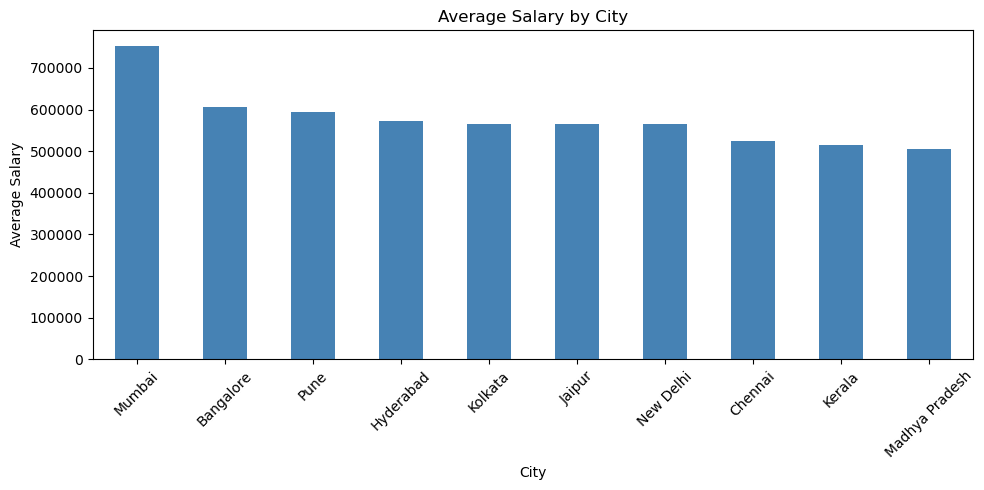

In [21]:
city_salary.plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title("Average Salary by City")
plt.xlabel("City")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
job_role = df_clean.groupby('Job Roles')['Salary'].mean().sort_values(ascending = False)
print(job_role)

Job Roles
Database    745670.833333
SDE         693104.775386
Mobile      648251.121076
IOS         617741.013470
Backend     574203.926740
Frontend    532927.754789
Android     501886.106443
Java        493755.957895
Testing     474144.130006
Python      460101.327641
Web         395296.404040
Name: Salary, dtype: float64


## 9. Job Role-wise Salary Analysis

**Finding:** Which job role pays the most?

- **Database** roles pay the most (₹7,50,000+ avg)
- **SDE** is second highest (₹7,00,000 avg)
- **Web** development pays the least (₹3,95,000 avg)
- Tip: Learn Database skills for highest salary!

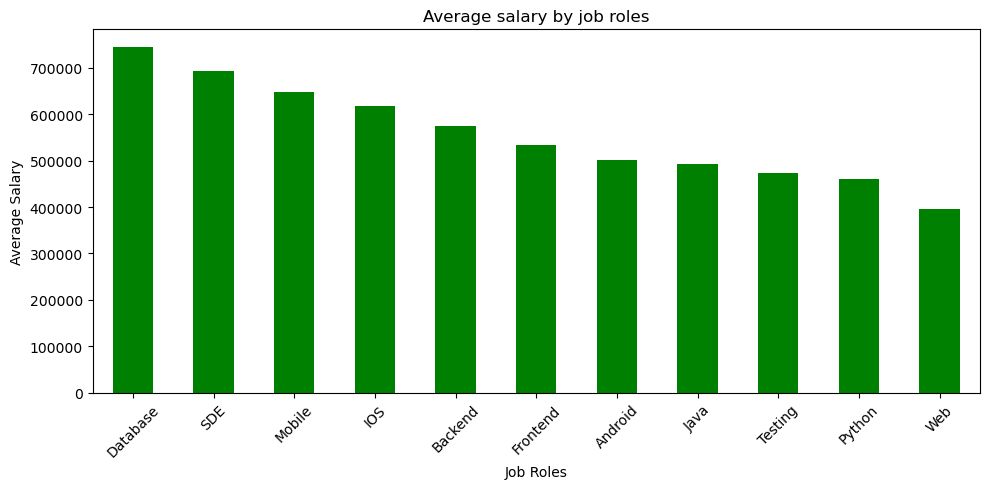

In [26]:
job_role.plot(kind='bar', color='green', figsize=(10,5))
plt.title('Average salary by job roles')
plt.xlabel('Job Roles')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Correlation Analysis — Rating vs Salary

**Question:** Does a company's rating affect the salary?

- **Correlation = 0.028** → Almost zero!
- **Conclusion:** Company rating has NO effect on salary
- A 3-star company can pay more than a 5-star company!

In [27]:
# correlation between rating and salary
correlation= df_clean['Rating'].corr(df_clean['Salary'])
print('Correlation between Rating and Salary',correlation)

Correlation between Rating and Salary 0.028435446014226973


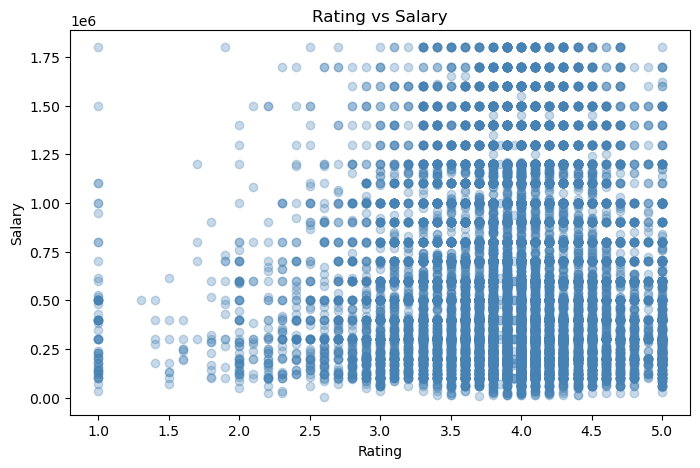

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Rating'], df_clean['Salary'], alpha=0.3, color='steelblue')
plt.title("Rating vs Salary")
plt.xlabel("Rating")
plt.ylabel("Salary")
plt.show()

## 11. Key Insights & Conclusions

### What we found from 22,770 India Job Records:

1. **Mumbai pays the most** — ₹7,52,751 avg (24% more than Bangalore)
2. **Database roles pay the most** — ₹7,50,000+ avg
3. **Web development pays the least** — ₹3,95,000 avg
4. **Company rating does NOT affect salary** — Correlation = 0.028
5. **Median is more reliable than Mean** — Outliers inflated mean by ₹1.1 lakh
6. **5% data were outliers** — 1,156 records removed using IQR method
7. **Skewness improved** from 46.79 → 0.99 after cleaning

### Tools & Methods Used:
- **Outlier Detection:** IQR Method (skewness was 46.79 — too extreme for SD method)
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn
- **Dataset:** 22,770 rows, 8 columns